# EDA

In [ ]:
import sys, pandas as pd
import chardet
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns


# adds parent file of the current directory
# to the paths in which Python looks for modules to import
# in the current Python process
sys.path.append(str(Path.cwd().parent))

from config import DATA_RAW_DIR, ROOT
from utils.cleaning_utils import delete, normalize_all_text_columns, fill_rate
from utils.analysis_utils import plot_missing_bar, plot_numeric_histograms, plot_corr_heatmap, plot_qualitative


### Création des constantes
- ALL_DATA_FILES : toutes les données
- POST_2005_DATA_FILES : données à partir de 2006 (modélisation définies en 2006)

Vérification de l'encodage : utf-8 à 81 % de confiance

In [96]:
# List all CSV files in DATA_RAW
ALL_DATA_FILES = list(iter(DATA_RAW_DIR.glob('*.csv')))

# List all recent CSV files in DATA_RAW, post 2006, without 2003 file
POST_2005_DATA_FILES = list(iter(DATA_RAW_DIR.glob('Incendies20*.csv')))
POST_2005_DATA_FILES = [f for f in POST_2005_DATA_FILES if "2003" and "2001" not in str(f)]

In [97]:
for file in POST_2005_DATA_FILES:
    print(f"File: {file.name}")

File: Incendies2011.csv
File: Incendies2006.csv
File: Incendies2016.csv
File: Incendies2021.csv


In [98]:
# Check the encoding of the CSV files
for file in POST_2005_DATA_FILES:
    with open(Path(DATA_RAW_DIR / 'Incendies1971.csv'), 'rb') as file:
        encodage = chardet.detect(file.read(10000))

    print(encodage)

{'encoding': 'utf-8', 'confidence': 0.812768, 'language': 'fr', 'mime_type': 'text/plain'}
{'encoding': 'utf-8', 'confidence': 0.812768, 'language': 'fr', 'mime_type': 'text/plain'}
{'encoding': 'utf-8', 'confidence': 0.812768, 'language': 'fr', 'mime_type': 'text/plain'}
{'encoding': 'utf-8', 'confidence': 0.812768, 'language': 'fr', 'mime_type': 'text/plain'}


In [99]:
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

### Création d'un dictionnaire avec les Données à partir de 2006
suppression des lignes d'introduction superflues

In [100]:
def get_skiprows(file):
    '''Delete the first rows of the file until the header row is found
       The header row is identified by the presence of the string "Année" at the beginning of the line'''
    with open(file, encoding="utf-8") as f:
        for i, line in enumerate(f):
            if line.startswith("Année"):
                return i
    return 0

# returns a dict of dataframes from the CSV files
# uses the year as the key
# delete the first rows of the file until the header row is found
incendies_dict = {
    int(file.stem.replace("Incendies", "")): pd.read_csv(
        file,
        encoding=encodage["encoding"],
        sep=";",
        skiprows=get_skiprows(file)
    )
    for file in POST_2005_DATA_FILES
}

In [101]:
len(incendies_dict)
incendies_dict.keys()

dict_keys([2011, 2006, 2016, 2021])

In [102]:
# Concatene les dataframes en un seul dataframe
df = pd.concat(incendies_dict.values(), ignore_index=True)

In [103]:
df.shape

(52806, 24)

In [104]:
df.head()

,Année,Numéro,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),Autres surfaces naturelles hors forêt (m2),Surfaces agricoles (m2),Autres surfaces (m2),Surface autres terres boisées (m2),Surfaces non boisées naturelles (m2),Surfaces non boisées artificialisées (m2),Surfaces non boisées (m2),Précision des surfaces,Type de peuplement,Nature,Décès ou bâtiments touchés,Nombre de décès,Nombre de bâtiments totalement détruits,Nombre de bâtiments partiellement détruits,Précision de la donnée
0,2011,7064,2A,2A198,Ota,2011-01-01 00:33:00,50,24.0,24.0,0.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,Involontaire (particulier),NaN,NaN,NaN,NaN,NaN
1,2011,7931,11,11203,Lézignan-Corbières,2011-01-02 09:10:00,1,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,4479,974,97415,Saint-Paul,2011-01-03 12:00:00,40000,40000.0,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,Estimées,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,7942,11,11203,Lézignan-Corbières,2011-01-06 11:01:00,1,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,4297,40,40113,Goos,2011-01-08 08:48:00,2000,2000.0,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,Involontaire (particulier),NaN,NaN,NaN,NaN,NaN


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52806 entries, 0 to 52805
Data columns (total 24 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Année                                       52806 non-null  int64  
 1   Numéro                                      52806 non-null  int64  
 2   Département                                 52806 non-null  str    
 3   Code INSEE                                  52806 non-null  str    
 4   Nom de la commune                           52779 non-null  str    
 5   Date de première alerte                     52806 non-null  str    
 6   Surface parcourue (m2)                      52806 non-null  int64  
 7   Surface forêt (m2)                          48156 non-null  float64
 8   Surface maquis garrigues (m2)               28073 non-null  float64
 9   Autres surfaces naturelles hors forêt (m2)  34531 non-null  float64
 10  Surfaces agricoles (m

In [106]:
df.describe()

,Année,Numéro,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),Autres surfaces naturelles hors forêt (m2),Surfaces agricoles (m2),Autres surfaces (m2),Surface autres terres boisées (m2),Surfaces non boisées naturelles (m2),Surfaces non boisées artificialisées (m2),Surfaces non boisées (m2),Type de peuplement,Nombre de décès,Nombre de bâtiments totalement détruits,Nombre de bâtiments partiellement détruits
count,52806.000000,52806.000000,5.280600e+04,4.815600e+04,2.807300e+04,3.453100e+04,6.588000e+03,6.572000e+03,1.702800e+04,1.069500e+04,1.042800e+04,3.561800e+04,20983.000000,1204.000000,1205.000000,1203.000000
mean,2015.523899,7794.866019,4.667073e+04,2.911151e+04,2.454000e+04,4.446331e+03,3.433630e+03,7.147463e+02,7.844942e+03,5.671529e+03,2.667294e+03,5.413967e+03,2.021684,0.004153,0.214938,0.128013
std,5.759668,5774.540433,1.005202e+06,8.733843e+05,4.223217e+05,6.215662e+04,5.781287e+04,2.807489e+04,8.084908e+04,1.174062e+05,3.996218e+04,1.033295e+05,1.458692,0.064335,3.668956,2.330491
min,2006.000000,1.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000,0.000000
25%,2010.000000,3264.250000,1.500000e+02,2.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000,0.000000
50%,2016.000000,7092.500000,1.000000e+03,2.000000e+02,3.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000,0.000000
75%,2021.000000,10985.000000,1.000000e+04,3.000000e+03,3.840000e+03,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+02,0.000000e+00,0.000000e+00,1.500000e+01,3.000000,0.000000,0.000000,0.000000
max,2025.000000,29813.000000,1.255200e+08,1.255200e+08,5.116000e+07,4.916000e+06,4.050000e+06,2.064500e+06,4.916000e+06,8.187317e+06,2.200000e+06,1.132000e+07,6.000000,1.000000,80.000000,74.000000


In [107]:
df.columns

Index(['Année', 'Numéro', 'Département', 'Code INSEE', 'Nom de la commune',
       'Date de première alerte', 'Surface parcourue (m2)',
       'Surface forêt (m2)', 'Surface maquis garrigues (m2)',
       'Autres surfaces naturelles hors forêt (m2)', 'Surfaces agricoles (m2)',
       'Autres surfaces (m2)', 'Surface autres terres boisées (m2)',
       'Surfaces non boisées naturelles (m2)',
       'Surfaces non boisées artificialisées (m2)',
       'Surfaces non boisées (m2)', 'Précision des surfaces',
       'Type de peuplement', 'Nature', 'Décès ou bâtiments touchés',
       'Nombre de décès', 'Nombre de bâtiments totalement détruits',
       'Nombre de bâtiments partiellement détruits', 'Précision de la donnée'],
      dtype='str')

## Sélection et Supression des variables inutiles
list `to_drop` et `dropped_cols` :
- 'Numéro'
- 'Année'
- 'Nom de la commune'
- 'Décès ou bâtiments touchés'
- 'Nombre de décès'
- 'Nombre de bâtiments totalement détruits'
- 'Nombre de bâtiments partiellement détruits'
- 'Précision des surfaces'
- 'Précision de la donnée'

In [108]:
# list of columns to drop
to_drop = [
    'Numéro',
    'Année',
    'Nom de la commune',
    'Décès ou bâtiments touchés',
    'Nombre de décès',
    'Nombre de bâtiments totalement détruits',
    'Nombre de bâtiments partiellement détruits',
    'Précision des surfaces',
    'Précision de la donnée'
]

dropped_cols = []


In [93]:
# df['Numéro'].value_counts()
# df['Année'].value_counts()
# df['Nom de la commune'].value_counts()
# df['Décès ou bâtiments touchés'].value_counts()
# df['Nombre de décès'].value_counts()
# df['Nombre de bâtiments totalement détruits'].value_counts()
# df['Nombre de bâtiments partiellement détruits'].value_counts()
# df['Précision des surfaces'].value_counts()
# df['Précision dela donnée'].value_counts()

In [109]:
# Delete the unwanted columns

# Attention : la fonction retourne un nouveau DataFrame, il faut le réaffecter.
for col in to_drop:
    df = delete(df, col, dropped_cols)


In [110]:
df.shape

(52806, 15)

In [111]:
df.columns

Index(['Département', 'Code INSEE', 'Date de première alerte',
       'Surface parcourue (m2)', 'Surface forêt (m2)',
       'Surface maquis garrigues (m2)',
       'Autres surfaces naturelles hors forêt (m2)', 'Surfaces agricoles (m2)',
       'Autres surfaces (m2)', 'Surface autres terres boisées (m2)',
       'Surfaces non boisées naturelles (m2)',
       'Surfaces non boisées artificialisées (m2)',
       'Surfaces non boisées (m2)', 'Type de peuplement', 'Nature'],
      dtype='str')

### Recherche de variable vide ou à une seule modalité

In [115]:
# Détection des variables qui n'ont qu'une seule modalité
# NaN étant considéré comme une modalité .....  (dropna=False)
unique_value_cols = df.columns[df.nunique(dropna=False)==1].tolist()
unique_value_cols

[]

In [116]:
# Détection des variables vide
empty = df.columns[df.isna().all()].tolist()
empty

[]

## Etats des données avant traitement

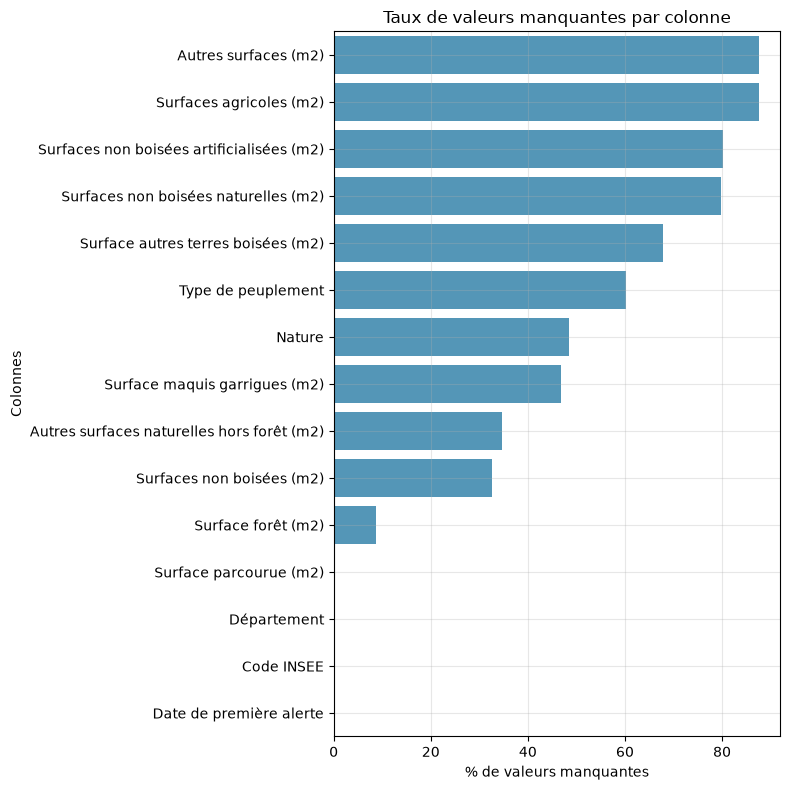

In [112]:
plot_missing_bar(df, figsize=(8,8))

### Type de surface brulée

Normalisation utile pour :

Logistic Regression
SVM
KNN
réseaux de neurones
PCA

En revanche, pour des modèles à arbres comme :

DecisionTree
RandomForest
ExtraTrees
Gradient Boosting

le scaling est généralement inutile.

In [ ]:

'Surface forêt (m2)'
'Surface maquis garrigues (m2)'
'Autres surfaces naturelles hors forêt (m2)'
'Surfaces agricoles (m2)'
'Autres surfaces (m2)'
'Surface autres terres boisées (m2)'
'Surfaces non boisées naturelles (m2)',
'Surfaces non boisées artificialisées (m2)',
'Surfaces non boisées (m2)'


In [121]:

df['Surfaces agricoles (m2)'].value_counts()

Surfaces agricoles (m2)
0.0         6353
30000.0       13
10000.0       13
20000.0       10
5000.0        10
            ... 
450000.0       1
22600.0        1
13300.0        1
16300.0        1
1.0            1
Name: count, Length: 135, dtype: int64

Il faut one hot encoder :
- les variables de type de surfaces
- 'Type de peuplement'

Quel methode ?
- LabelEncoder()
- OrdinalEncoder()
- LabelBinarizer()
- MultiLabelBinarizer()
- OneHotEncoder()

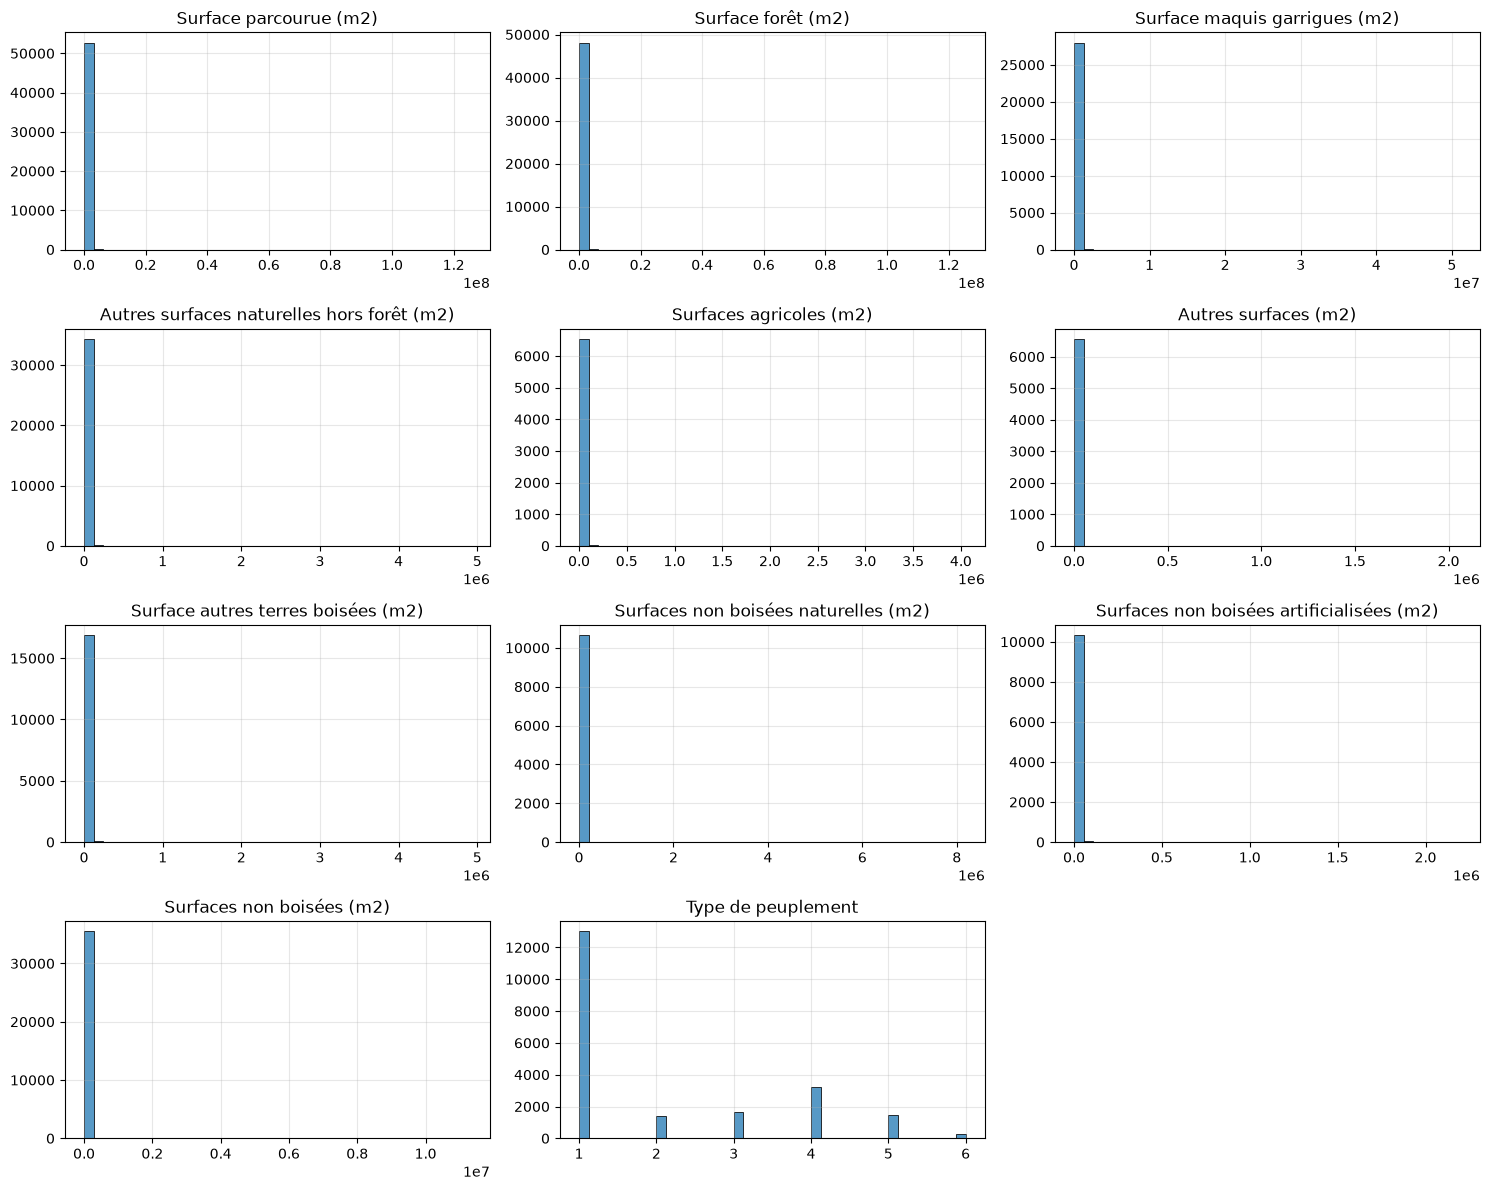

In [113]:
plot_numeric_histograms(df, bins=40, n_cols=3)

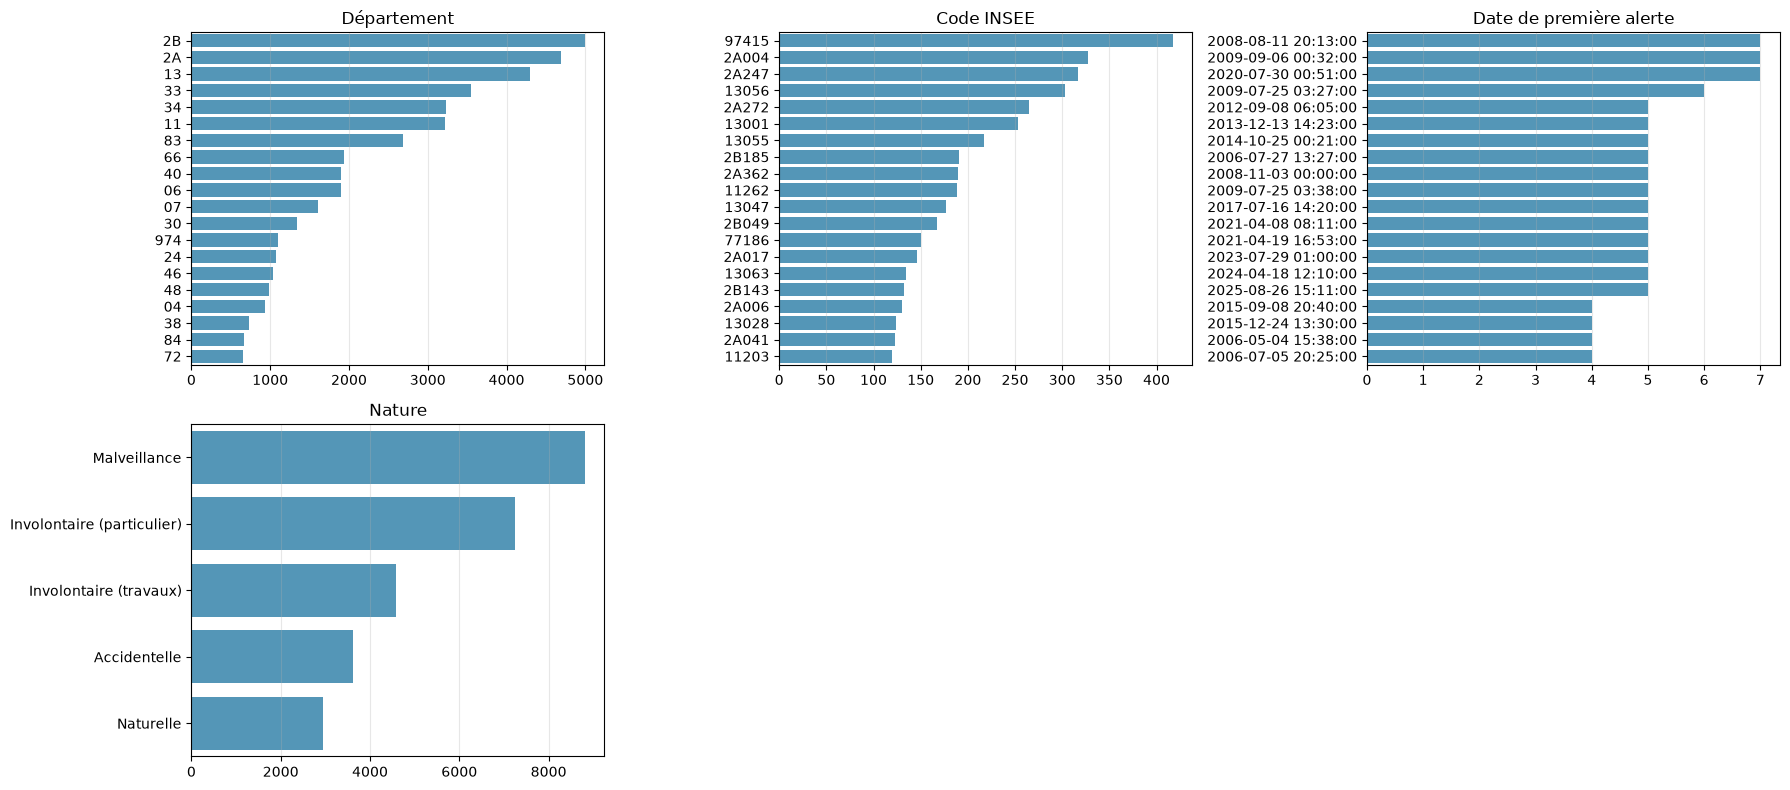

In [114]:
plot_qualitative(df, n_cols=3)

In [85]:
df['Type de peuplement'].value_counts()

Type de peuplement
1.0    13006
4.0     3226
3.0     1651
5.0     1446
2.0     1399
6.0      255
Name: count, dtype: int64

Surface autres terres boisées (m2)
0.0        10540
10000.0      622
5000.0       392
20000.0      372
100.0        362
           ...  
6861.0         1
21889.0        1
6716.0         1
55342.0        1
40372.0        1
Name: count, Length: 391, dtype: int64